In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Calibration from Market Data

In [3]:
# ==============================
# Settings
# ==============================
ticker = "AAPL"
start_date = "2021-01-01"
end_date = "2026-01-01"  # end date is excluded

# ==============================
# Download Apple price data
# ==============================
apple = yf.Ticker(ticker)

data = apple.history(
    start=start_date,
    end=end_date,
    interval="1d",
    auto_adjust=True
)

# Keep the required columns
data = data[["Open", "High", "Low", "Close", "Volume"]]

print(data.head())
print(data.tail())
print("\nNumber of trading days:", len(data))

# Save the data to a CSV file
data.to_csv("AAPL_2021_2025.csv")

print("Data saved as AAPL_2021_2025.csv")

# Read the data back from the CSV file
data = pd.read_csv(
    "AAPL_2021_2025.csv",
    index_col="Date",
    parse_dates=True
)

# Check for missing values and duplicate dates
print("Missing values:")
print(data.isna().sum())

print("\nDuplicate dates:")
print(data.index.duplicated().sum())

print("\nDate range:")
print(data.index.min(), "to", data.index.max())

                                 Open        High         Low       Close  \
Date                                                                        
2021-01-04 00:00:00-05:00  129.734370  129.821814  123.166031  125.740898   
2021-01-05 00:00:00-05:00  125.235577  128.004777  124.788613  127.295464   
2021-01-06 00:00:00-05:00  124.098776  127.334363  122.796765  123.010529   
2021-01-07 00:00:00-05:00  124.720617  127.897907  124.234793  127.208031   
2021-01-08 00:00:00-05:00  128.675200  128.869542  126.537580  128.305984   

                              Volume  
Date                                  
2021-01-04 00:00:00-05:00  143301900  
2021-01-05 00:00:00-05:00   97664900  
2021-01-06 00:00:00-05:00  155088000  
2021-01-07 00:00:00-05:00  109578200  
2021-01-08 00:00:00-05:00  105158200  
                                 Open        High         Low       Close  \
Date                                                                        
2025-12-24 00:00:00-05:00  271.83

In [6]:
# Daily log return
data["Log_Return"] = np.log(data["Close"] / data["Close"].shift(1))

# Remove the first missing return
returns = data["Log_Return"].dropna()

# Summary statistics
mean_daily_return = returns.mean()
daily_volatility = returns.std(ddof=1)
annualised_volatility = daily_volatility * np.sqrt(252)

print(f"Number of price observations: {len(data)}")
print(f"Number of return observations: {len(returns)}")
print(f"Mean daily log return: {mean_daily_return:.6f}")
print(f"Daily volatility: {daily_volatility:.6f}")
print(f"Annualised volatility: {annualised_volatility:.6f}")
print(f"Annualised volatility: {annualised_volatility:.2%}")

Number of price observations: 1255
Number of return observations: 1254
Mean daily log return: 0.000613
Daily volatility: 0.017490
Annualised volatility: 0.277646
Annualised volatility: 27.76%


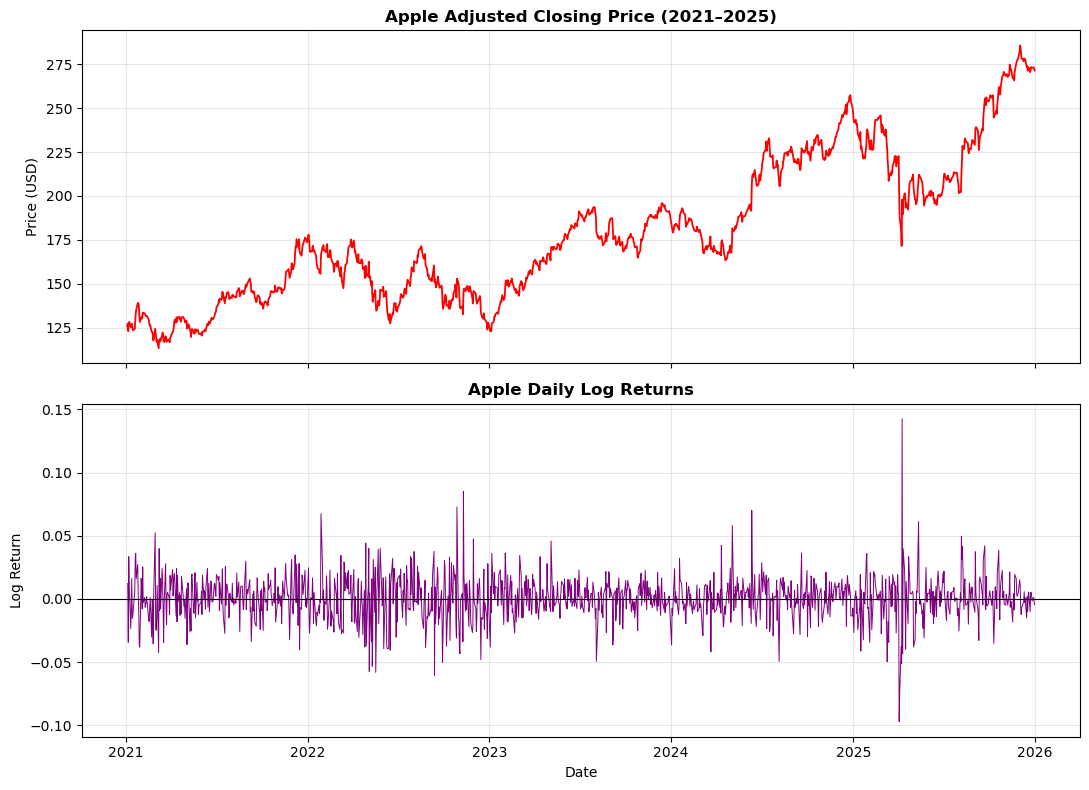

In [53]:
fig, axes = plt.subplots(
    2, 1,
    figsize=(11, 8),
    sharex=True
)

# Adjusted closing price
axes[0].plot(
    data.index,
    data["Close"],
    color="red",
    linewidth=1.3
)

axes[0].set_title(
    "Apple Adjusted Closing Price (2021–2025)",
    fontweight="bold"
)
axes[0].set_ylabel("Price (USD)")
axes[0].grid(alpha=0.3)

# Daily log returns
axes[1].plot(
    data.index,
    data["Log_Return"],
    color="purple",
    linewidth=0.7
)

axes[1].axhline(
    0,
    color="black",
    linewidth=0.8
)

axes[1].set_title(
    "Apple Daily Log Returns",
    fontweight="bold"
)
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Log Return")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Step 2: Simulation of Brownian Motion

In [8]:
# Settings for the simulation
T = 1.0                   # simulation period: one year
num_steps = 252           # number of trading days
num_paths = 10000         # number of simulated paths
dt = T / num_steps

# Reproducible random number generator
rng = np.random.default_rng(seed=42)

# Time grid: 0, 1/252, ..., 1
time_grid = np.linspace(0, T, num_steps + 1)

# Independent standard normal random variables
Z = rng.standard_normal(
    size=(num_paths, num_steps)
)

# Standard Brownian increments:
# dW ~ N(0, dt)
dW = np.sqrt(dt) * Z

# Standard Brownian motion W, including W_0 = 0
W = np.column_stack([
    np.zeros(num_paths),
    np.cumsum(dW, axis=1)
])

# Volatility-scaled process:
# X_t = sigma_hat * W_t
X = annualised_volatility * W

# Terminal values
W_T = W[:, -1]
X_T = X[:, -1]

print("Number of simulated paths:", num_paths)
print(
    f"Estimated annualised volatility: "
    f"{annualised_volatility:.2%}"
)

print("\nStandard Brownian motion")
print(f"Mean of W_T: {W_T.mean():.4f}")
print(f"Standard deviation of W_T: {W_T.std(ddof=1):.4f}")

print("\nVolatility-scaled process")
print(f"Mean of X_T: {X_T.mean():.4f}")
print(f"Standard deviation of X_T: {X_T.std(ddof=1):.4f}")

Number of simulated paths: 10000
Estimated annualised volatility: 27.76%

Standard Brownian motion
Mean of W_T: 0.0088
Standard deviation of W_T: 0.9997

Volatility-scaled process
Mean of X_T: 0.0024
Standard deviation of X_T: 0.2776


展示前50条路径（仅查看）

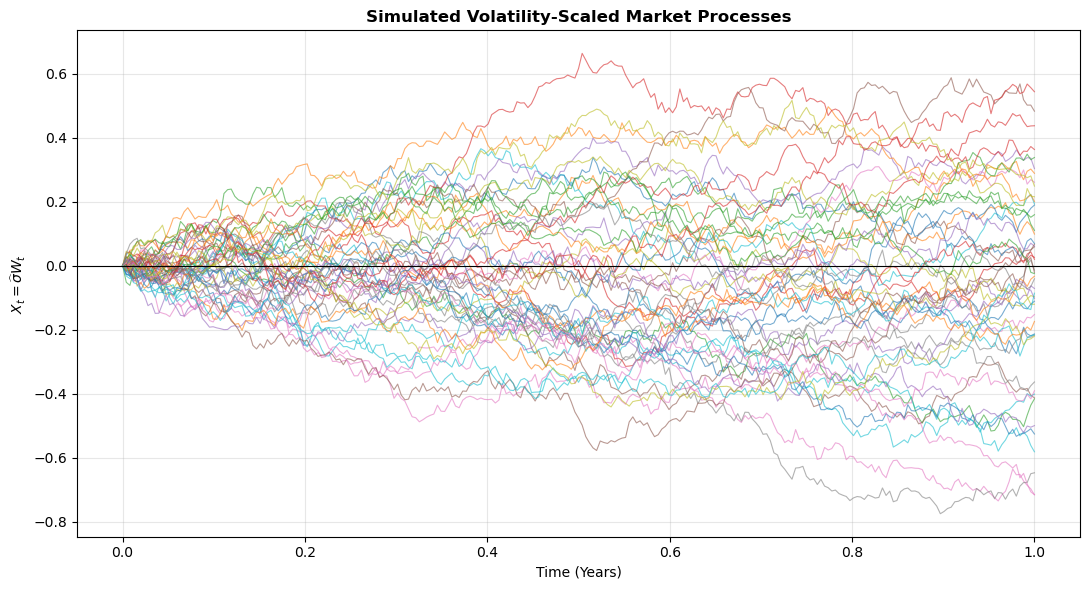

In [9]:
plt.figure(figsize=(11, 6))

num_paths_to_plot = 50

for i in range(num_paths_to_plot):
    plt.plot(
        time_grid,
        X[i],
        linewidth=0.8,
        alpha=0.6
    )

plt.axhline(
    y=0,
    color="black",
    linewidth=0.8
)

plt.title(
    "Simulated Volatility-Scaled Market Processes",
    fontweight="bold"
)
plt.xlabel("Time (Years)")
plt.ylabel(r"$X_t=\widehat{\sigma}W_t$")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

所有终点值的直方图

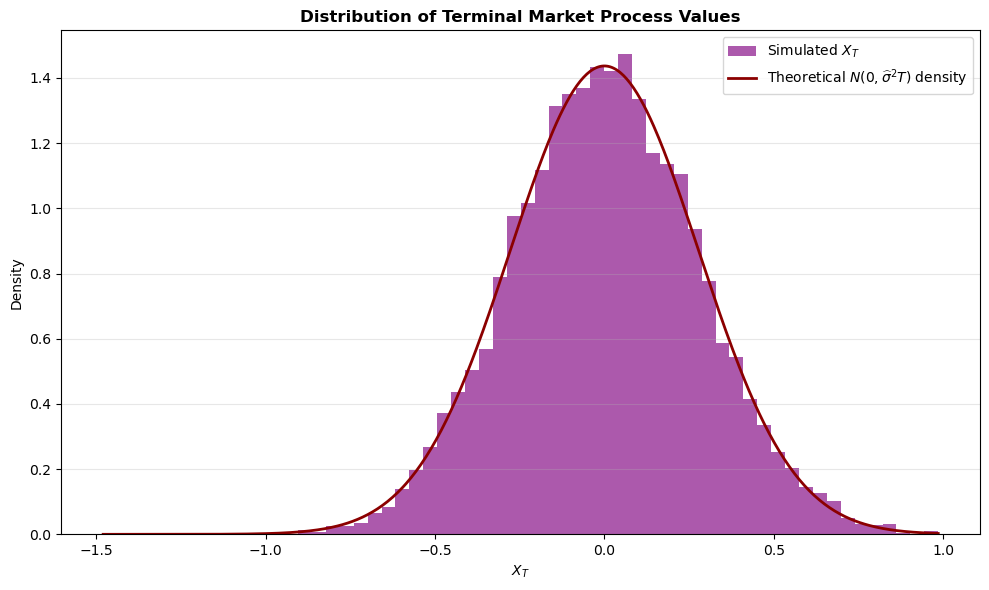

In [10]:
from scipy.stats import norm

plt.figure(figsize=(10, 6))

plt.hist(
    X_T,
    bins=60,
    density=True,
    color="purple",
    alpha=0.65,
    label=r"Simulated $X_T$"
)

x_values = np.linspace(
    X_T.min(),
    X_T.max(),
    500
)

theoretical_std = annualised_volatility * np.sqrt(T)

theoretical_density = norm.pdf(
    x_values,
    loc=0,
    scale=theoretical_std
)

plt.plot(
    x_values,
    theoretical_density,
    color="darkred",
    linewidth=2,
    label=r"Theoretical $N(0,\widehat{\sigma}^2T)$ density"
)

plt.title(
    "Distribution of Terminal Market Process Values",
    fontweight="bold"
)
plt.xlabel(r"$X_T$")
plt.ylabel("Density")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Step 3: 构造 Apple 的 GBM 价格 $S_t$，还需要算$\widehat{\mu}$

# Step 3: Enlargement of Filtration （ε不匹配

构造带噪声信息

In [ ]:
# Noise levels specified in the experiment
epsilon_values = np.array([
    0.05,
    0.10,
    0.25,
    0.50,
    1.00
])

# Generate independent standard normal noise for each simulated path
noise_Z = rng.standard_normal(num_paths)

# Construct the noisy signals: G_epsilon = X_T + epsilon * noise_Z
G_epsilon = {
    epsilon: X_T + epsilon * noise_Z
    for epsilon in epsilon_values
}

print("Noisy information signals")

for epsilon in epsilon_values:
    signal = G_epsilon[epsilon]

    print(f"\nepsilon = {epsilon:.2f}")
    print(f"Mean of G_epsilon: {signal.mean():.4f}")
    print(
        f"Standard deviation of G_epsilon: "
        f"{signal.std(ddof=1):.4f}"
    )
    print(
        f"Correlation between X_T and G_epsilon: "
        f"{np.corrcoef(X_T, signal)[0, 1]:.4f}"
    )

Noisy information signals

epsilon = 0.05
Mean of G_epsilon: 0.0025
Standard deviation of G_epsilon: 0.2818
Correlation between X_T and G_epsilon: 0.9838

epsilon = 0.10
Mean of G_epsilon: 0.0026
Standard deviation of G_epsilon: 0.2947
Correlation between X_T and G_epsilon: 0.9393

epsilon = 0.25
Mean of G_epsilon: 0.0029
Standard deviation of G_epsilon: 0.3739
Correlation between X_T and G_epsilon: 0.7371

epsilon = 0.50
Mean of G_epsilon: 0.0034
Standard deviation of G_epsilon: 0.5748
Correlation between X_T and G_epsilon: 0.4761

epsilon = 1.00
Mean of G_epsilon: 0.0045
Standard deviation of G_epsilon: 1.0463
Correlation between X_T and G_epsilon: 0.2578


每条模拟路径上的信号

In [14]:
path_index = 0

print(f"Selected path: {path_index}")
print(f"True terminal value X_T: {X_T[path_index]:.4f}")

for epsilon in epsilon_values:
    print(
        f"epsilon = {epsilon:.2f}, "
        f"G_epsilon = "
        f"{G_epsilon[epsilon][path_index]:.4f}"
    )

Selected path: 0
True terminal value X_T: -0.2132
epsilon = 0.05, G_epsilon = -0.2456
epsilon = 0.10, G_epsilon = -0.2780
epsilon = 0.25, G_epsilon = -0.3753
epsilon = 0.50, G_epsilon = -0.5374
epsilon = 1.00, G_epsilon = -0.8615


In [15]:
# Compare simulated results with theoretical values
print("\nComparison with theoretical values")

for epsilon in epsilon_values:
    signal = G_epsilon[epsilon]

    simulated_std = signal.std(ddof=1)
    theoretical_std = np.sqrt(
        annualised_volatility ** 2 * T
        + epsilon ** 2
    )

    simulated_corr = np.corrcoef(
        X_T,
        signal
    )[0, 1]

    theoretical_corr = (
        annualised_volatility * np.sqrt(T)
        / theoretical_std
    )

    print(f"\nepsilon = {epsilon:.2f}")
    print(
        f"Simulated standard deviation: "
        f"{simulated_std:.4f}"
    )
    print(
        f"Theoretical standard deviation: "
        f"{theoretical_std:.4f}"
    )
    print(
        f"Simulated correlation: "
        f"{simulated_corr:.4f}"
    )
    print(
        f"Theoretical correlation: "
        f"{theoretical_corr:.4f}"
    )


Comparison with theoretical values

epsilon = 0.05
Simulated standard deviation: 0.2818
Theoretical standard deviation: 0.2821
Simulated correlation: 0.9838
Theoretical correlation: 0.9842

epsilon = 0.10
Simulated standard deviation: 0.2947
Theoretical standard deviation: 0.2951
Simulated correlation: 0.9393
Theoretical correlation: 0.9408

epsilon = 0.25
Simulated standard deviation: 0.3739
Theoretical standard deviation: 0.3736
Simulated correlation: 0.7371
Theoretical correlation: 0.7431

epsilon = 0.50
Simulated standard deviation: 0.5748
Theoretical standard deviation: 0.5719
Simulated correlation: 0.4761
Theoretical correlation: 0.4855

epsilon = 1.00
Simulated standard deviation: 1.0463
Theoretical standard deviation: 1.0378
Simulated correlation: 0.2578
Theoretical correlation: 0.2675


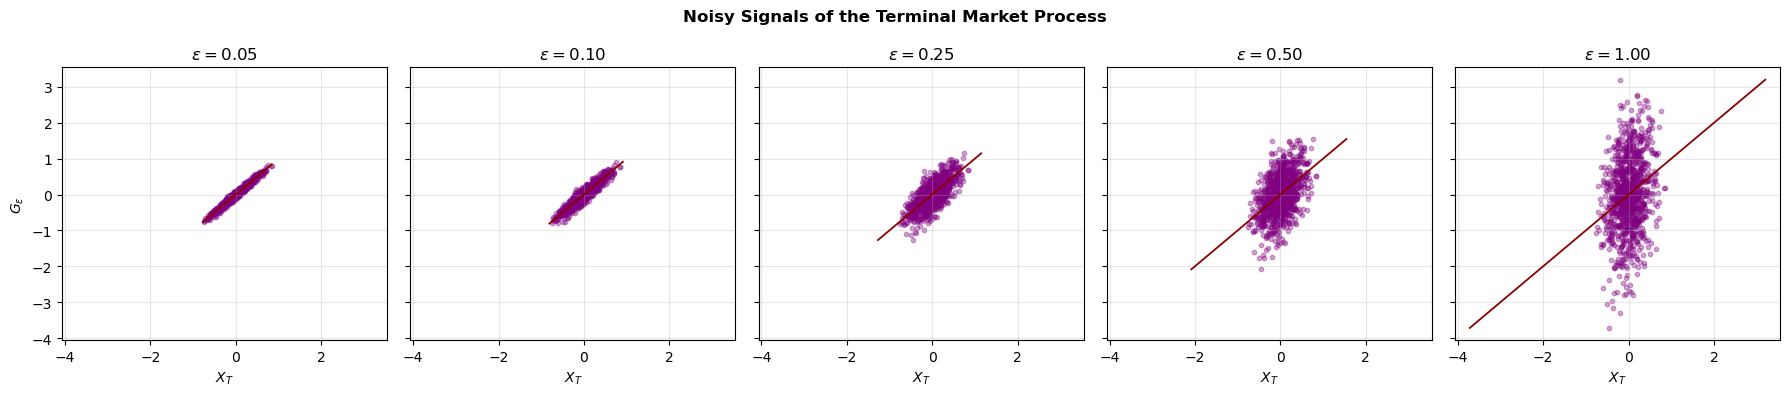

In [16]:
fig, axes = plt.subplots(
    1,
    len(epsilon_values),
    figsize=(18, 4),
    sharex=True,
    sharey=True
)

# Use at most 1000 points to keep the plots clear
plot_indices = np.arange(min(1000, num_paths))

for ax, epsilon in zip(axes, epsilon_values):
    signal = G_epsilon[epsilon]

    ax.scatter(
        X_T[plot_indices],
        signal[plot_indices],
        color="purple",
        alpha=0.35,
        s=10
    )

    lower_limit = min(
        X_T[plot_indices].min(),
        signal[plot_indices].min()
    )

    upper_limit = max(
        X_T[plot_indices].max(),
        signal[plot_indices].max()
    )

    # Perfect-information reference line
    ax.plot(
        [lower_limit, upper_limit],
        [lower_limit, upper_limit],
        color="darkred",
        linewidth=1.3
    )

    ax.set_title(
        rf"$\varepsilon={epsilon:.2f}$",
        fontweight="bold"
    )
    ax.set_xlabel(r"$X_T$")
    ax.grid(alpha=0.3)

axes[0].set_ylabel(r"$G_\varepsilon$")

plt.suptitle(
    "Noisy Signals of the Terminal Market Process",
    fontweight="bold"
)
plt.tight_layout()
plt.show()

# Step 3: Enlargement of Filtration

构造带噪声信息

In [11]:
# Relative noise levels
relative_noise_levels = np.array([
    0.05,
    0.10,
    0.25,
    0.50,
    1.00
])

# Standard deviation of the terminal market process X_T
std_X_T = annualised_volatility * np.sqrt(T)

# Convert relative noise levels into absolute noise levels:
# epsilon_lambda = lambda * sigma_hat * sqrt(T)
epsilon_values = (
    relative_noise_levels * std_X_T
)

# Generate noise independent of the Brownian motion
# One independent noise observation for each simulated path
noise_Z = rng.standard_normal(num_paths)

# Construct the noisy signals:
# G_lambda = X_T + epsilon_lambda * noise_Z
G_lambda = {
    relative_noise: (
        X_T
        + epsilon * noise_Z
    )
    for relative_noise, epsilon in zip(
        relative_noise_levels,
        epsilon_values
    )
}

print("Standard deviation of X_T:", f"{std_X_T:.4f}")

for relative_noise, epsilon in zip(
    relative_noise_levels,
    epsilon_values
):
    signal = G_lambda[relative_noise]

    simulated_correlation = np.corrcoef(
        X_T,
        signal
    )[0, 1]

    theoretical_correlation = (
        1 / np.sqrt(1 + relative_noise ** 2)
    )

    print(f"\nRelative noise level λ = {relative_noise:.2f}")
    print(f"Absolute noise level ε = {epsilon:.4f}")
    print(
        "Simulated standard deviation of G: "
        f"{signal.std(ddof=1):.4f}"
    )
    print(
        "Simulated correlation Corr(X_T, G): "
        f"{simulated_correlation:.4f}"
    )
    print(
        "Theoretical correlation: "
        f"{theoretical_correlation:.4f}"
    )

Standard deviation of X_T: 0.2776

Relative noise level λ = 0.05
Absolute noise level ε = 0.0139
Simulated standard deviation of G: 0.2778
Simulated correlation Corr(X_T, G): 0.9987
Theoretical correlation: 0.9988

Relative noise level λ = 0.10
Absolute noise level ε = 0.0278
Simulated standard deviation of G: 0.2788
Simulated correlation Corr(X_T, G): 0.9949
Theoretical correlation: 0.9950

Relative noise level λ = 0.25
Absolute noise level ε = 0.0694
Simulated standard deviation of G: 0.2858
Simulated correlation Corr(X_T, G): 0.9694
Theoretical correlation: 0.9701

Relative noise level λ = 0.50
Absolute noise level ε = 0.1388
Simulated standard deviation of G: 0.3101
Simulated correlation Corr(X_T, G): 0.8917
Theoretical correlation: 0.8944

Relative noise level λ = 1.00
Absolute noise level ε = 0.2776
Simulated standard deviation of G: 0.3932
Simulated correlation Corr(X_T, G): 0.7004
Theoretical correlation: 0.7071


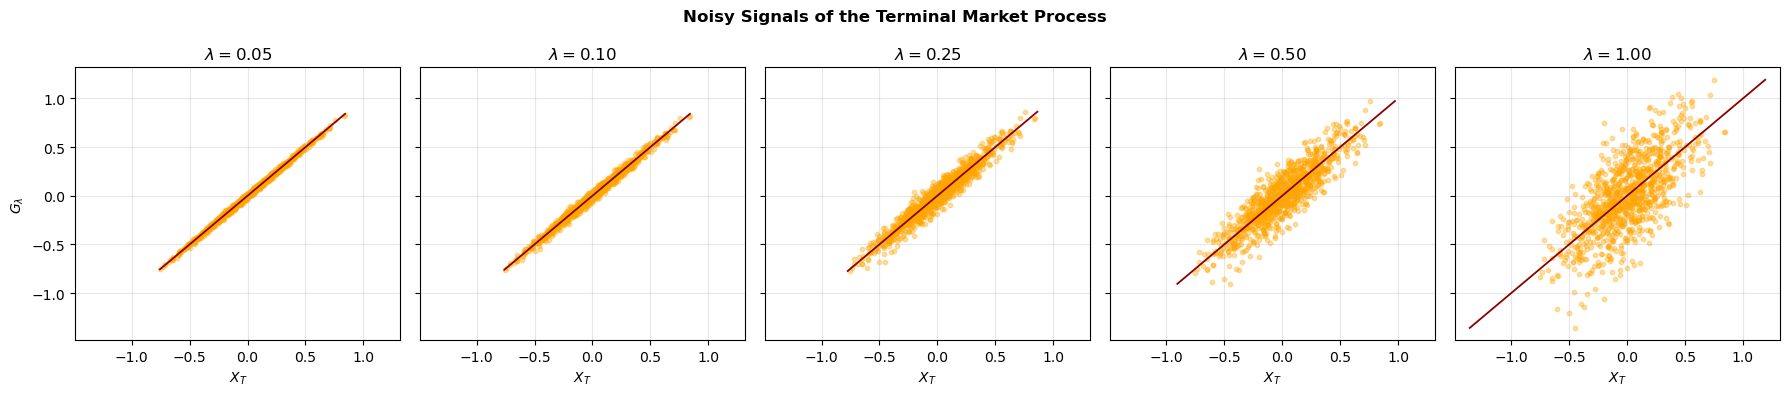

In [22]:
fig, axes = plt.subplots(
    1,
    len(relative_noise_levels),
    figsize=(18, 4),
    sharex=True,
    sharey=True
)

plot_indices = np.arange(min(1000, num_paths))

for ax, relative_noise in zip(
    axes,
    relative_noise_levels
):
    signal = G_lambda[relative_noise]

    ax.scatter(
        X_T[plot_indices],
        signal[plot_indices],
        color="orange",
        alpha=0.35,
        s=10
    )

    lower_limit = min(
        X_T[plot_indices].min(),
        signal[plot_indices].min()
    )

    upper_limit = max(
        X_T[plot_indices].max(),
        signal[plot_indices].max()
    )

    # Perfect-information reference line
    ax.plot(
        [lower_limit, upper_limit],
        [lower_limit, upper_limit],
        color="darkred",
        linewidth=1.3
    )

    ax.set_title(
        rf"$\lambda={relative_noise:.2f}$",
        fontweight="bold"
    )
    ax.set_xlabel(r"$X_T$")
    ax.grid(alpha=0.3)

axes[0].set_ylabel(r"$G_\lambda$")

plt.suptitle(
    "Noisy Signals of the Terminal Market Process",
    fontweight="bold"
)
plt.tight_layout()
plt.show()

# Step 4: Estimation of Conditional Expectations

In [32]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Indices of all Monte Carlo paths
all_indices = np.arange(num_paths)

# Use 80% of the paths for estimating the regression
# and 20% for evaluating and plotting the results
train_indices, test_indices = train_test_split(
    all_indices,
    test_size=0.20,
    random_state=42
)

print("Number of training paths:", len(train_indices))
print("Number of test paths:", len(test_indices))

Number of training paths: 8000
Number of test paths: 2000


In [33]:
# Store estimated conditional expectations
m_monte_carlo = {}

# Store the fitted regression coefficients
regression_coefficients = {}

for relative_noise in relative_noise_levels:

    # Noisy signal corresponding to this λ
    signal = G_lambda[relative_noise]

    # Conditional expectation estimates for all test paths
    estimated_m = np.zeros(
        (len(test_indices), len(time_grid))
    )

    # Regression coefficients at each time point
    coefficient_results = np.zeros(
        (len(time_grid), 3)
    )

    for time_index in range(len(time_grid)):

        # -----------------------------
        # Monte Carlo training sample
        # -----------------------------

        # Explanatory variables:
        # current market value X_t and noisy signal G_lambda
        training_inputs = np.column_stack([
            X[train_indices, time_index],
            signal[train_indices]
        ])

        # Target variable: terminal value X_T
        training_target = X_T[train_indices]

        # Fit the regression
        regression_model = LinearRegression()

        regression_model.fit(
            training_inputs,
            training_target
        )

        # -----------------------------
        # Estimate m_t on test paths
        # -----------------------------

        test_inputs = np.column_stack([
            X[test_indices, time_index],
            signal[test_indices]
        ])

        estimated_m[:, time_index] = (
            regression_model.predict(test_inputs)
        )

        # Save intercept and coefficients
        coefficient_results[time_index, 0] = (
            regression_model.intercept_
        )

        coefficient_results[time_index, 1:] = (
            regression_model.coef_
        )

    # At t = T, X_T has already been observed
    estimated_m[:, -1] = X_T[test_indices]

    m_monte_carlo[relative_noise] = estimated_m

    regression_coefficients[relative_noise] = (
        coefficient_results
    )

print("Monte Carlo regression completed.")

Monte Carlo regression completed.


In [34]:
for relative_noise in relative_noise_levels:
    print(
        f"λ = {relative_noise:.2f}, "
        f"shape = "
        f"{m_monte_carlo[relative_noise].shape}"
    )

λ = 0.05, shape = (2000, 253)
λ = 0.10, shape = (2000, 253)
λ = 0.25, shape = (2000, 253)
λ = 0.50, shape = (2000, 253)
λ = 1.00, shape = (2000, 253)


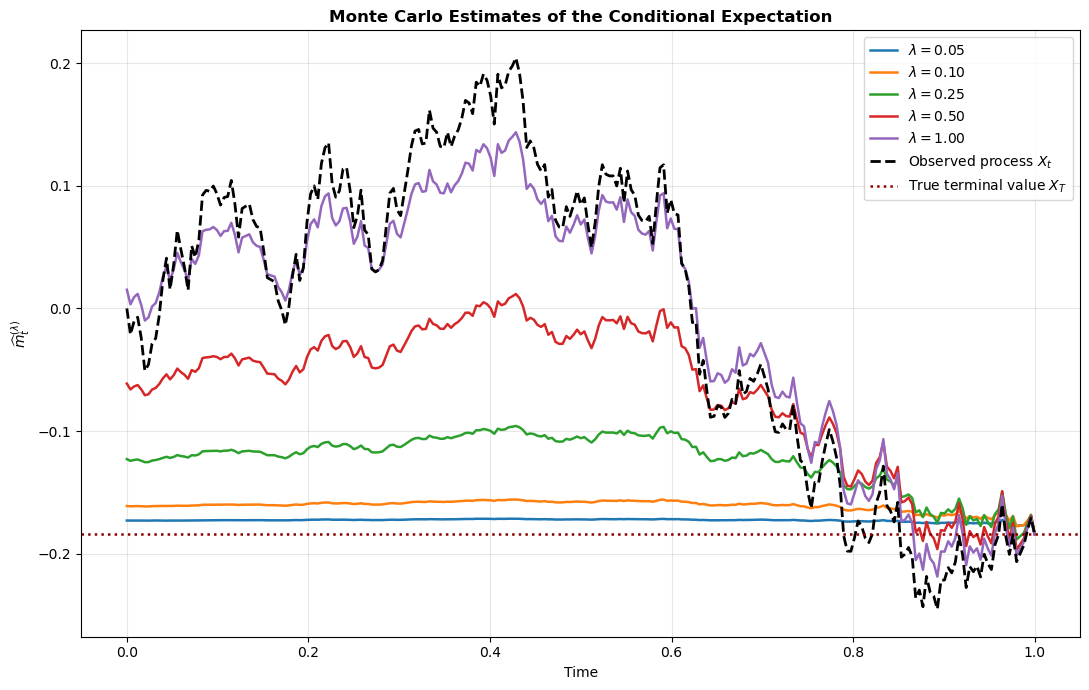

In [35]:
# Select one path from the test sample
test_path_position = 0

# Its original position among all simulated paths
original_path_index = test_indices[test_path_position]

plt.figure(figsize=(11, 7))

for relative_noise in relative_noise_levels:
    plt.plot(
        time_grid,
        m_monte_carlo[relative_noise][
            test_path_position
        ],
        linewidth=1.8,
        label=rf"$\lambda={relative_noise:.2f}$"
    )

# Observed path of X_t
plt.plot(
    time_grid,
    X[original_path_index],
    color="black",
    linewidth=2,
    linestyle="--",
    label=r"Observed process $X_t$"
)

# True terminal value
plt.axhline(
    X_T[original_path_index],
    color="darkred",
    linewidth=1.8,
    linestyle=":",
    label=r"True terminal value $X_T$"
)

plt.title(
    "Monte Carlo Estimates of the Conditional Expectation",
    fontweight="bold"
)

plt.xlabel("Time")
plt.ylabel(r"$\widehat{m}_t^{(\lambda)}$")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

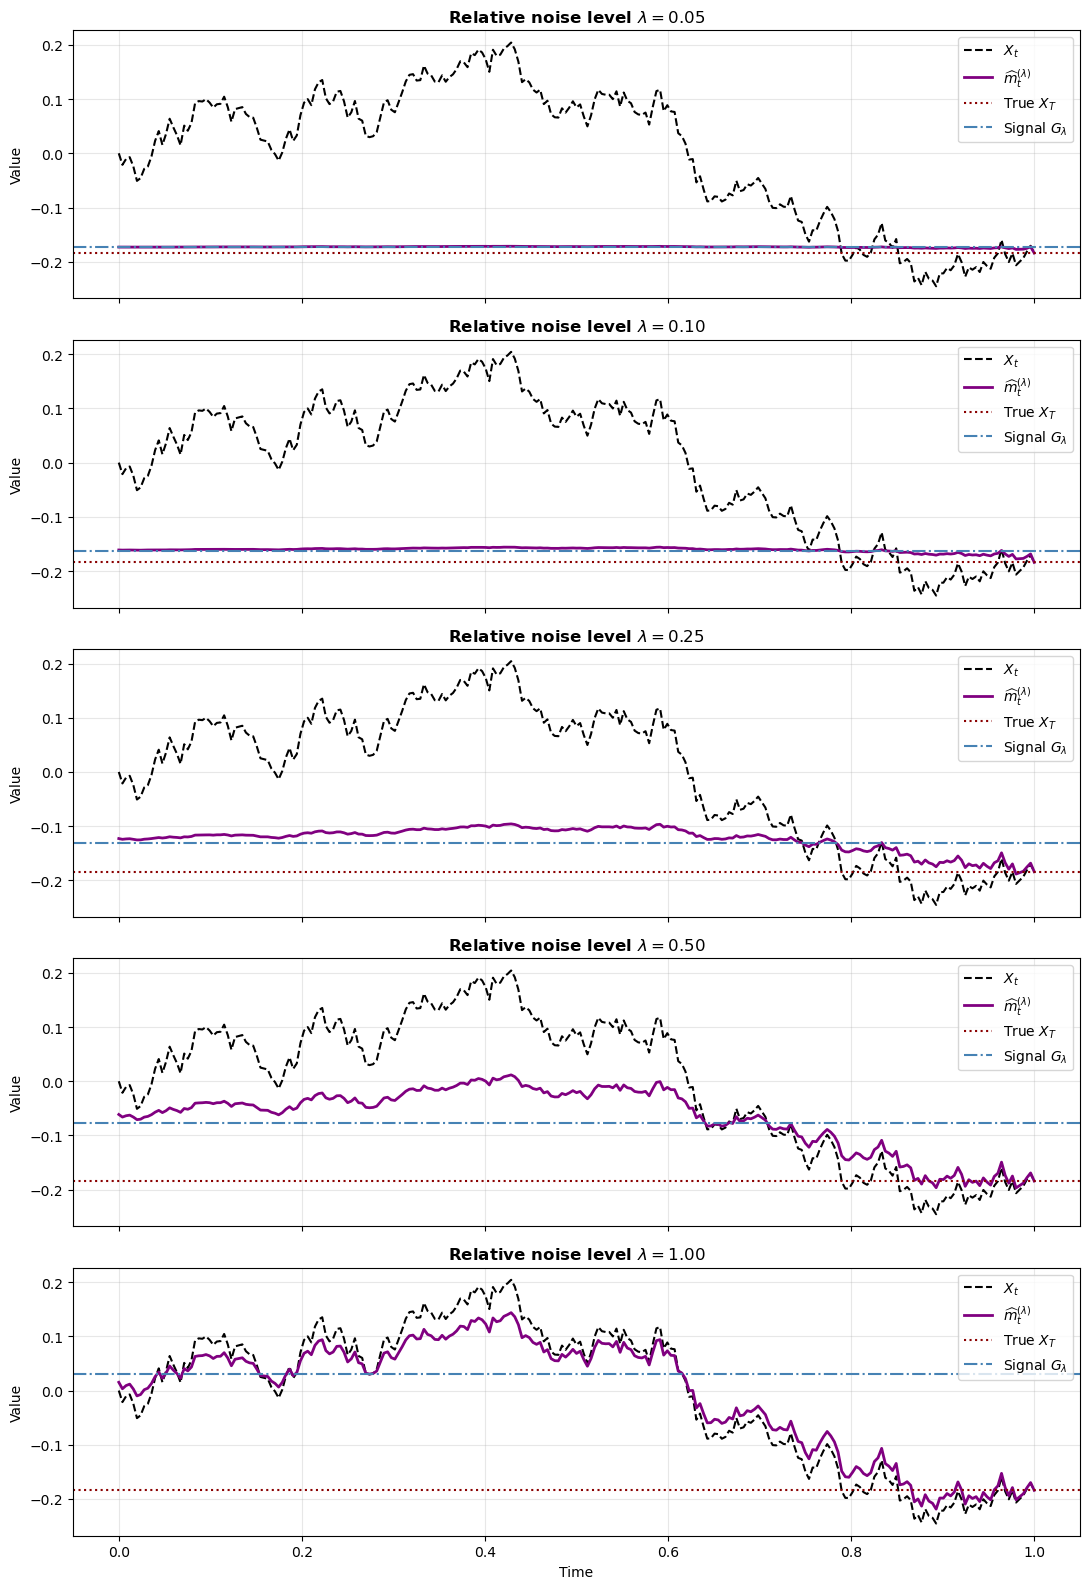

In [36]:
fig, axes = plt.subplots(
    len(relative_noise_levels),
    1,
    figsize=(11, 16),
    sharex=True
)

for ax, relative_noise in zip(
    axes,
    relative_noise_levels
):
    signal_value = G_lambda[
        relative_noise
    ][original_path_index]

    # Observed X_t
    ax.plot(
        time_grid,
        X[original_path_index],
        color="black",
        linewidth=1.5,
        linestyle="--",
        label=r"$X_t$"
    )

    # Monte Carlo estimate of m_t
    ax.plot(
        time_grid,
        m_monte_carlo[relative_noise][
            test_path_position
        ],
        color="purple",
        linewidth=2,
        label=r"$\widehat{m}_t^{(\lambda)}$"
    )

    # Actual terminal value
    ax.axhline(
        X_T[original_path_index],
        color="darkred",
        linewidth=1.5,
        linestyle=":",
        label=r"True $X_T$"
    )

    # Noisy signal
    ax.axhline(
        signal_value,
        color="steelblue",
        linewidth=1.5,
        linestyle="-.",
        label=r"Signal $G_\lambda$"
    )

    ax.set_title(
        rf"Relative noise level "
        rf"$\lambda={relative_noise:.2f}$",
        fontweight="bold"
    )

    ax.set_ylabel("Value")
    ax.grid(alpha=0.3)
    ax.legend(loc="best")

axes[-1].set_xlabel("Time")

plt.tight_layout()
plt.show()

# Step 5: Computation of the Information Drift

In [37]:
# Use the annualised volatility estimated in Step 1
sigma_hat = annualised_volatility

# Remaining time before T
time_to_maturity = T - time_grid

# Store information-drift paths
alpha_monte_carlo = {}

for relative_noise in relative_noise_levels:

    # X paths corresponding to the test sample
    X_test = X[test_indices]

    # Step 4 Monte Carlo estimate of
    # E[X_T | X_t, G_lambda]
    estimated_m = m_monte_carlo[relative_noise]

    # Store alpha for all test paths and all time points
    estimated_alpha = np.full_like(
        estimated_m,
        np.nan,
        dtype=float
    )

    # Calculate only for t < T
    estimated_alpha[:, :-1] = (
        estimated_m[:, :-1]
        - X_test[:, :-1]
    ) / (
        sigma_hat
        * time_to_maturity[:-1]
    )

    # alpha is undefined at t = T
    estimated_alpha[:, -1] = np.nan

    alpha_monte_carlo[relative_noise] = (
        estimated_alpha
    )

print("Information-drift paths computed.")

Information-drift paths computed.


In [38]:
for relative_noise in relative_noise_levels:
    print(
        f"λ = {relative_noise:.2f}, "
        f"shape = "
        f"{alpha_monte_carlo[relative_noise].shape}"
    )

λ = 0.05, shape = (2000, 253)
λ = 0.10, shape = (2000, 253)
λ = 0.25, shape = (2000, 253)
λ = 0.50, shape = (2000, 253)
λ = 1.00, shape = (2000, 253)


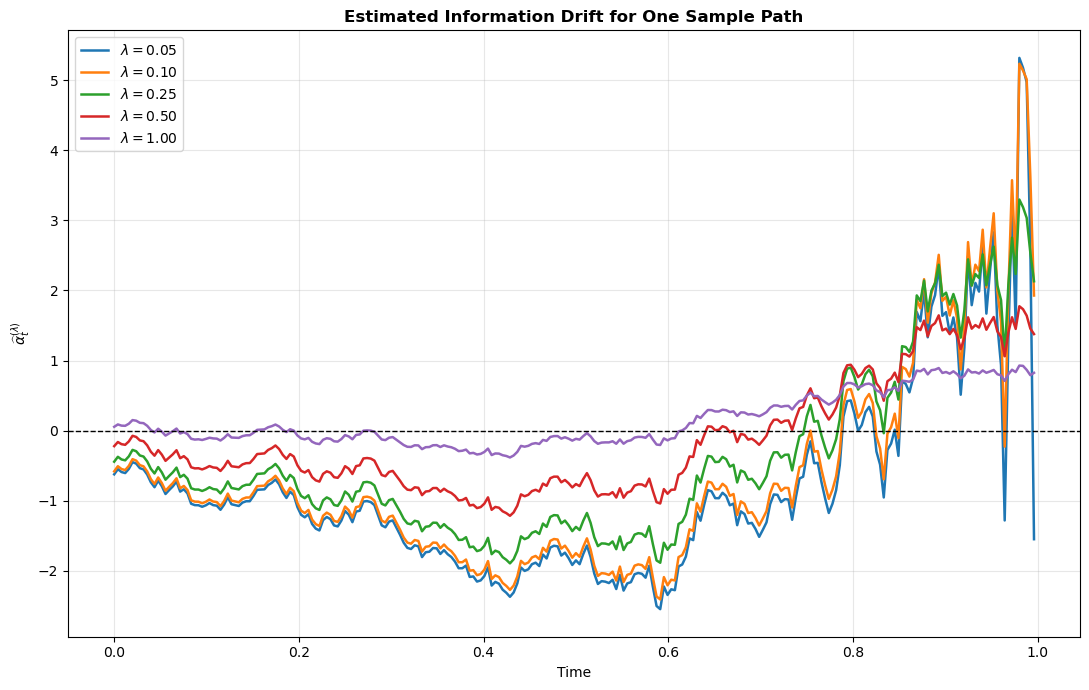

In [46]:
test_path_position = 0
original_path_index = test_indices[test_path_position]

plt.figure(figsize=(11, 7))

for relative_noise in relative_noise_levels:
    plt.plot(
        time_grid[:-1],
        alpha_monte_carlo[relative_noise][
            test_path_position, :-1
        ],
        linewidth=1.8,
        label=rf"$\lambda={relative_noise:.2f}$"
    )

plt.axhline(
    0,
    color="black",
    linewidth=1,
    linestyle="--"
)

plt.title(
    "Estimated Information Drift for One Sample Path",
    fontweight="bold"
)

plt.xlabel("Time")
plt.ylabel(r"$\widehat{\alpha}_t^{(\lambda)}$")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

αt mean

In [40]:
alpha_mean = {}

for relative_noise in relative_noise_levels:
    alpha_mean[relative_noise] = np.nanmean(
        alpha_monte_carlo[relative_noise],
        axis=0
    )

C:\Users\angel\AppData\Local\Temp\ipykernel_76040\3003783775.py:4: RuntimeWarning: Mean of empty slice
  alpha_mean[relative_noise] = np.nanmean(


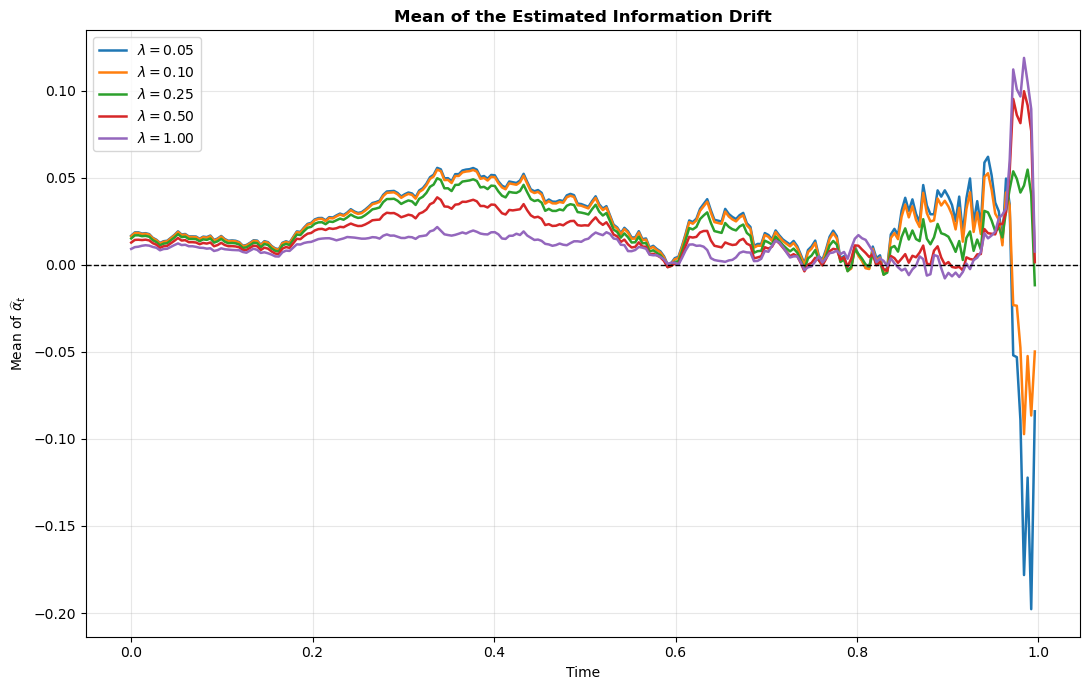

In [41]:
plt.figure(figsize=(11, 7))

for relative_noise in relative_noise_levels:
    plt.plot(
        time_grid[:-1],
        alpha_mean[relative_noise][:-1],
        linewidth=1.8,
        label=rf"$\lambda={relative_noise:.2f}$"
    )

plt.axhline(
    0,
    color="black",
    linewidth=1,
    linestyle="--"
)

plt.title(
    "Mean of the Estimated Information Drift",
    fontweight="bold"
)

plt.xlabel("Time")
plt.ylabel(r"Mean of $\widehat{\alpha}_t$")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

αt​ variance

In [47]:
alpha_variance = {}

for relative_noise in relative_noise_levels:
    alpha_variance[relative_noise] = np.nanvar(
        alpha_monte_carlo[relative_noise],
        axis=0,
        ddof=1
    )

C:\Users\angel\AppData\Local\Temp\ipykernel_76040\1034007430.py:4: RuntimeWarning: Degrees of freedom <= 0 for slice.
  alpha_variance[relative_noise] = np.nanvar(


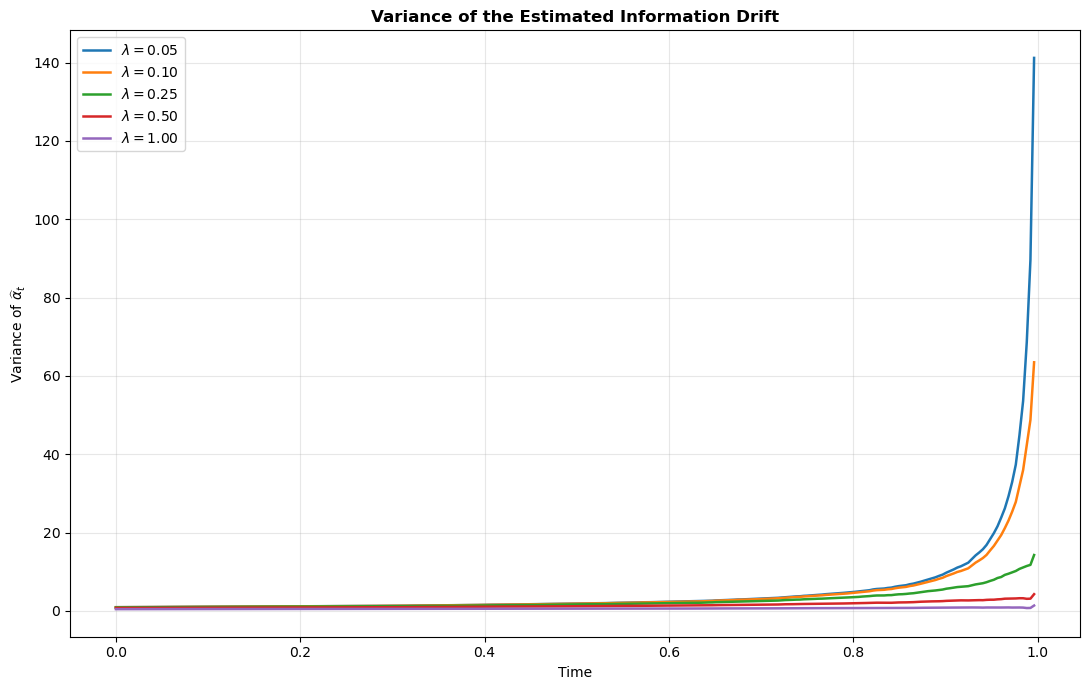

In [48]:
plt.figure(figsize=(11, 7))

for relative_noise in relative_noise_levels:
    plt.plot(
        time_grid[:-1],
        alpha_variance[relative_noise][:-1],
        linewidth=1.8,
        label=rf"$\lambda={relative_noise:.2f}$"
    )

plt.title(
    "Variance of the Estimated Information Drift",
    fontweight="bold"
)

plt.xlabel("Time")
plt.ylabel(
    r"Variance of $\widehat{\alpha}_t$"
)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

t close to T

In [52]:
number_of_final_points = 25

for relative_noise in relative_noise_levels:

    print(
        f"\nNoise level λ = "
        f"{relative_noise:.2f}"
    )

    for time_index in range(
        len(time_grid) - number_of_final_points,
        len(time_grid) - 1
    ):
        print(
            f"t = {time_grid[time_index]:.4f}, "
            f"mean = "
            f"{alpha_mean[relative_noise][time_index]: .6f}, "
            f"variance = "
            f"{alpha_variance[relative_noise][time_index]: .6f}"
        )


Noise level λ = 0.05
t = 0.9048, mean =  0.034302, variance =  10.173942
t = 0.9087, mean =  0.025052, variance =  10.588295
t = 0.9127, mean =  0.039138, variance =  11.067970
t = 0.9167, mean =  0.017647, variance =  11.406479
t = 0.9206, mean =  0.038126, variance =  11.871012
t = 0.9246, mean =  0.049547, variance =  12.319996
t = 0.9286, mean =  0.023814, variance =  13.256258
t = 0.9325, mean =  0.036524, variance =  14.175819
t = 0.9365, mean =  0.022467, variance =  14.921491
t = 0.9405, mean =  0.058687, variance =  15.750092
t = 0.9444, mean =  0.062011, variance =  16.850596
t = 0.9484, mean =  0.051396, variance =  18.378968
t = 0.9524, mean =  0.035696, variance =  19.854800
t = 0.9563, mean =  0.030673, variance =  21.608983
t = 0.9603, mean =  0.013102, variance =  23.818485
t = 0.9643, mean =  0.049487, variance =  26.172891
t = 0.9683, mean =  0.034845, variance =  29.271451
t = 0.9722, mean = -0.051992, variance =  32.901705
t = 0.9762, mean = -0.053064, variance =  

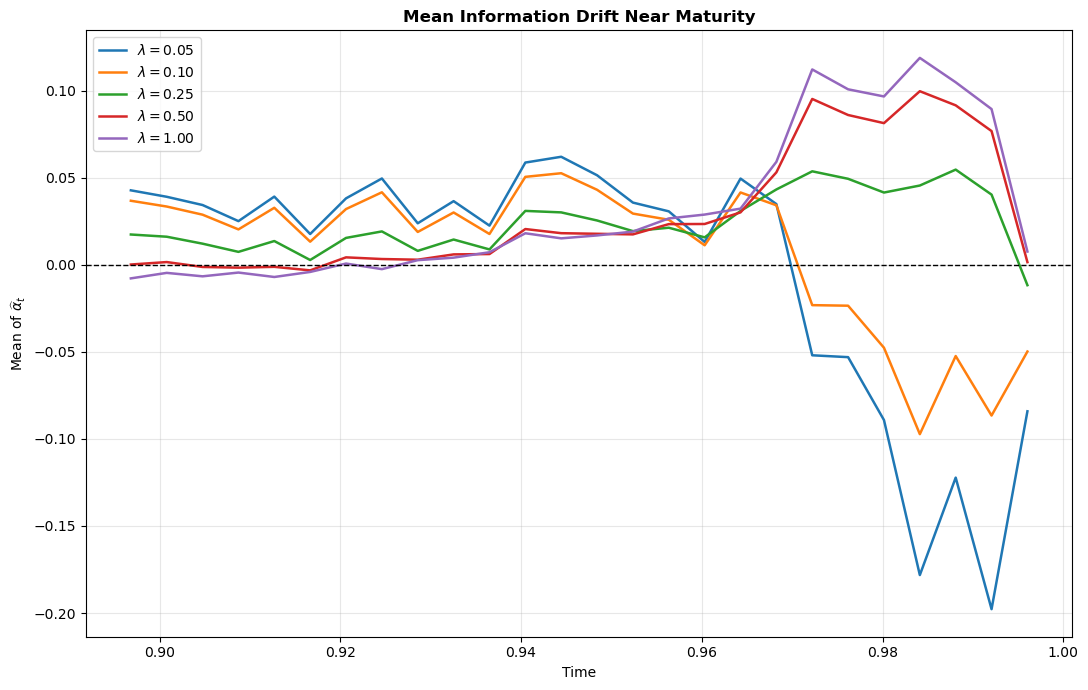

In [54]:
terminal_start_index = int(
    0.90 * (len(time_grid) - 1)
)

plt.figure(figsize=(11, 7))

for relative_noise in relative_noise_levels:
    plt.plot(
        time_grid[terminal_start_index:-1],
        alpha_mean[relative_noise][
            terminal_start_index:-1
        ],
        linewidth=1.8,
        label=rf"$\lambda={relative_noise:.2f}$"
    )

plt.axhline(
    0,
    color="black",
    linewidth=1,
    linestyle="--"
)

plt.title(
    "Mean Information Drift Near Maturity",
    fontweight="bold"
)

plt.xlabel("Time")
plt.ylabel(r"Mean of $\widehat{\alpha}_t$")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

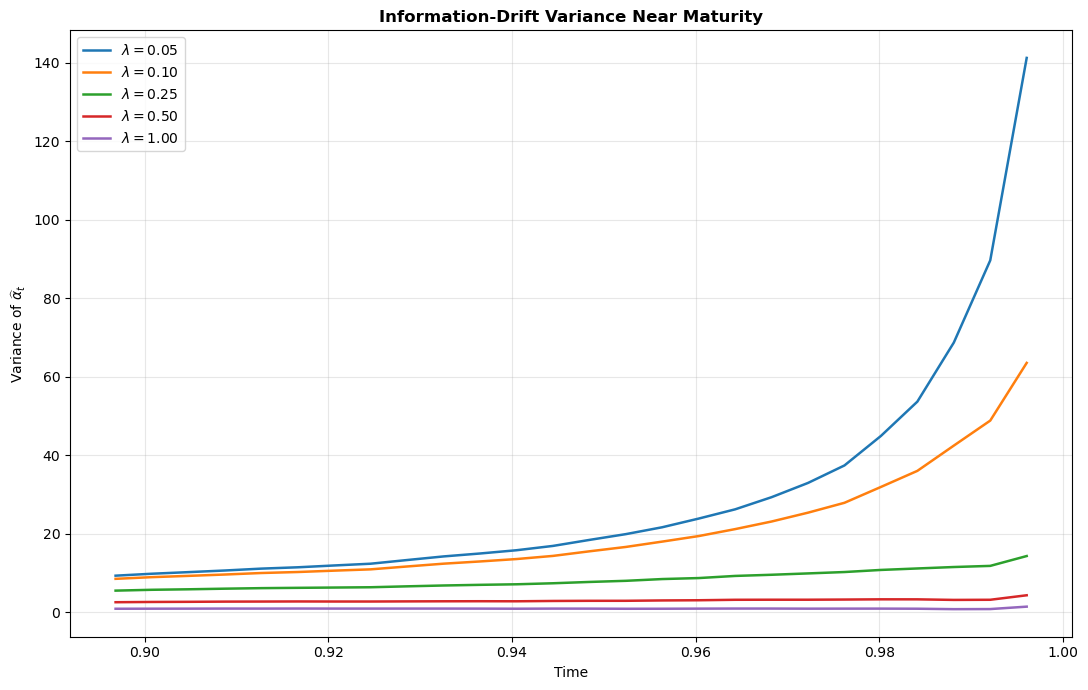

In [50]:
terminal_start_index = int(
    0.90 * (len(time_grid) - 1)
)

plt.figure(figsize=(11, 7))

for relative_noise in relative_noise_levels:
    plt.plot(
        time_grid[terminal_start_index:-1],
        alpha_variance[relative_noise][
            terminal_start_index:-1
        ],
        linewidth=1.8,
        label=rf"$\lambda={relative_noise:.2f}$"
    )

plt.title(
    "Information-Drift Variance Near Maturity",
    fontweight="bold"
)

plt.xlabel("Time")
plt.ylabel(
    r"Variance of $\widehat{\alpha}_t$"
)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Step 6: Measuring the Strength of the Enlargement